# 🌍 Análise de Desenvolvimento Humano (IDHM 2010)
# Pergunta Norteadora: "Quais são os Estados que possuem um bom IDH para que possamos entregar bons produtos?"

# ==============================================================================
# 1. SETUP E BIBLIOTECAS (Rigor de MLOps e Documentação)
# ==============================================================================

In [2]:
import os           # Gestão de arquivos e pastas no sistema operacional
import sys          # Parâmetros e funções específicas do sistema
from pathlib import Path # Manipulação moderna de caminhos de arquivos (POO)

import pandas as pd  # Ferramenta principal para análise e manipulação de DataFrames
import numpy as np   # Operações matemáticas e computação numérica eficiente

import matplotlib.pyplot as plt # Base para geração de gráficos estáticos
import seaborn as sns           # Interface de alto nível para gráficos estatísticos
import plotly.express as px     # Visualizações interativas (ideal para mapas)

import warnings                 # Controle de notificações e alertas
warnings.filterwarnings('ignore') # Silencia avisos para manter o output limpo

# Configurações de Rigor Visual
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option('display.max_columns', None)        
pd.set_option('display.float_format', '{:.4f}'.format) 

print("🚀 Ambiente configurado para análise estratégica de IDHM!")


🚀 Ambiente configurado para análise estratégica de IDHM!


# ==============================================================================
# 2. CARGA DOS DADOS (Data Acquisition - Aula 2.1)
# ==============================================================================

In [3]:
path_file = "../../Base de dados IDH/IDH_2010.xls"

try:
    idhm = pd.read_excel(path_file, engine='xlrd')
    print(f"✅ Sucesso! Arquivo carregado: {path_file}")
except Exception as e:
    print(f"❌ Erro crítico na carga: {e}")

✅ Sucesso! Arquivo carregado: ../../Base de dados IDH/IDH_2010.xls


# ==============================================================================
# 3. DATA CLEANING E TRANSFORMAÇÃO (Preparação da Base)
# ==============================================================================
# Seleção das colunas estratégicas

In [4]:
df_idhm = idhm[[
    'Nome da Unidade da Federação', 
    'Município', 
    'IDHM', 
    'IDHM Educação', 
    'IDHM Longevidade', 
    'IDHM Renda'
]].copy()

# Renomeação para snake_case (Removendo acentos e espaços)

In [5]:
df_idhm.columns = [
    'nome_da_unidade_da_federacao', 
    'municipio', 
    'idhm', 
    'idhm_educacao', 
    'idhm_longevidade', 
    'idhm_renda'
]

# ==============================================================================
# 4. IMPORTÂNCIA DA ESTATÍSTICA DESCRITIVA (Aula 2.2)
# ==============================================================================
# Aqui aplicamos o rigor matemático para entender a dispersão e tendência central

In [6]:
print("\n📊 ESTATÍSTICA DESCRITIVA DA BASE NACIONAL:")
display(df_idhm.describe())

# Insight estatístico: Verificando a assimetria (Skewness) do IDHM
media = df_idhm['idhm'].mean()
mediana = df_idhm['idhm'].median()

print(f"\n💡 Análise de Tendência Central:")
print(f"- Média Nacional: {media:.4f}")
print(f"- Mediana Nacional: {mediana:.4f}")

if media < mediana:
    print("- Resultado: Assimetria Negativa (A maioria dos municípios está acima da média.)")

# --- NOVO: Atendendo ao feedback do Professor ---
# Definindo a régua de corte para "Bom IDH" (Decisão de Negócio)
corte_bom_idh = 0.7

print(f"\n🎯 REGRA DE NEGÓCIO:")
print(f"- Definimos 'Bom IDH' como valores >= {corte_bom_idh} (Alto Desenvolvimento).")
print(f"- Isso nos permite focar nos estados/municípios que estão no topo do ranking nacional.")


📊 ESTATÍSTICA DESCRITIVA DA BASE NACIONAL:


,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,5564.0000,5564.0000,5564.0000,5564.0000
mean,0.6592,0.5591,0.8016,0.6429
std,0.0720,0.0933,0.0447,0.0807
min,0.4180,0.2070,0.6720,0.4000
25%,0.5990,0.4900,0.7690,0.5720
50%,0.6650,0.5600,0.8080,0.6540
75%,0.7180,0.6310,0.8360,0.7070
max,0.8620,0.8250,0.8940,0.8910



💡 Análise de Tendência Central:
- Média Nacional: 0.6592
- Mediana Nacional: 0.6650
- Resultado: Assimetria Negativa (A maioria dos municípios está acima da média.)

🎯 REGRA DE NEGÓCIO:
- Definimos 'Bom IDH' como valores >= 0.7 (Alto Desenvolvimento).
- Isso nos permite focar nos estados/municípios que estão no topo do ranking nacional.


# ==============================================================================
# 5. AGRUPANDO OS DADOS PARA A ANÁLISE (Aula 2.3)
# ==============================================================================
# Agrupando por Estado para identificar os "Mercados Premium"
# Incluímos a contagem de municípios para entender a capilaridade de cada Estado

In [7]:
# Agrupamento por UF
df_uf = df_idhm.groupby('nome_da_unidade_da_federacao').agg({
    'idhm': ['mean', 'median', 'std'],
    'municipio': 'count'
}).sort_values(by=('idhm', 'mean'), ascending=False)

# Renomeando colunas
df_uf.columns = ['idhm_medio', 'idhm_mediana', 'idhm_desvio_padrao', 'qtd_municipios']

# --- AJUSTE PARA O PROFESSOR ---
# 1. Tratar o NaN do DF (Desvio padrão de 1 item é 0)
df_uf['idhm_desvio_padrao'] = df_uf['idhm_desvio_padrao'].fillna(0)

# 2. Aplicar a Regra de Negócio (Status) baseada no corte de 0.7
df_uf['status_desenvolvimento'] = df_uf['idhm_medio'].apply(
    lambda x: '✅ Alto (Prioritário)' if x >= 0.7 else '⚠️ Médio/Baixo'
)

print("\n🏆 RANKING DE ESTADOS (Visão Estratégica de Vendas):")
display(df_uf)


🏆 RANKING DE ESTADOS (Visão Estratégica de Vendas):


,idhm_medio,idhm_mediana,idhm_desvio_padrao,qtd_municipios,status_desenvolvimento
nome_da_unidade_da_federacao,,,,,
Distrito Federal,0.8240,0.8240,0.0000,1,✅ Alto (Prioritário)
São Paulo,0.7395,0.7380,0.0325,645,✅ Alto (Prioritário)
Santa Catarina,0.7316,0.7360,0.0402,293,✅ Alto (Prioritário)
Rio Grande do Sul,0.7135,0.7170,0.0412,496,✅ Alto (Prioritário)
Rio de Janeiro,0.7089,0.7125,0.0368,92,✅ Alto (Prioritário)
Paraná,0.7020,0.7060,0.0386,399,✅ Alto (Prioritário)
Goiás,0.6950,0.6970,0.0335,246,⚠️ Médio/Baixo
Espírito Santo,0.6922,0.6835,0.0381,78,⚠️ Médio/Baixo
Mato Grosso,0.6843,0.6860,0.0383,141,⚠️ Médio/Baixo


# ==============================================================================
# 6. UTILIZANDO GRÁFICOS PARA DETERMINAR INSIGHTS (Aula 2.4)
# ==============================================================================
# 6.1. Visualização do Ranking de Mercado

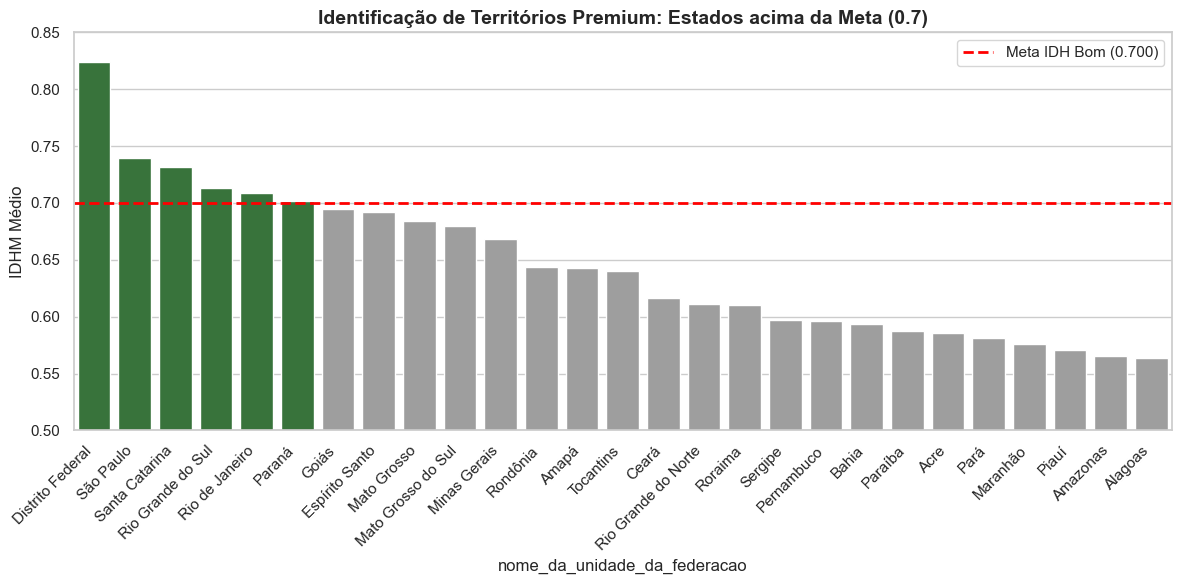

In [8]:
plt.figure(figsize=(12, 6))

# Criando uma lista de cores baseada na meta de 0.7
cores = ['#2E7D32' if valor >= 0.7 else '#9E9E9E' for valor in df_uf['idhm_medio']]

sns.barplot(x=df_uf.index, y=df_uf['idhm_medio'], palette=cores)

# IMPORTANTE: Trocando a linha da média pela linha da META de 0.7 solicitada pelo professor
plt.axhline(0.7, color='red', linestyle='--', linewidth=2, label='Meta IDH Bom (0.700)')

plt.title('Identificação de Territórios Premium: Estados acima da Meta (0.7)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('IDHM Médio')
plt.ylim(0.5, 0.85)
plt.legend()
plt.tight_layout()
plt.show()

# 6.2. Análise de Correlação entre as Dimensões (Insight de Produto)
# Para saber se o foco deve ser em renda ou longevidade/estilo de vida

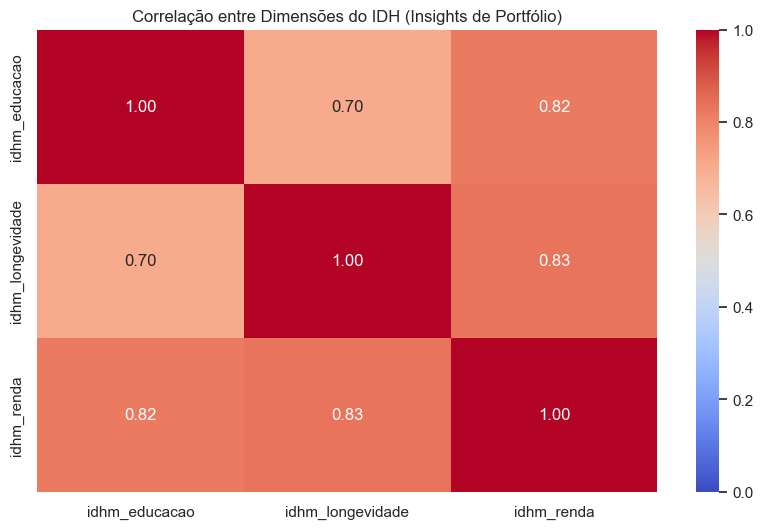

🧐 ANÁLISE DE CORRELAÇÃO (Deep Dive):
- Renda vs Educação (0.82): Correlação alta. Indica que estados com maior escolaridade são mercados com maior ticket médio.
- Renda vs Longevidade (0.83): A correlação mais forte. Sugere que mercados maduros (longevidade) têm maior estabilidade financeira para compras recorrentes.
- Insight de Negócio: O foco em 'Renda' é o Porto Seguro para vendas, mas a 'Educação' é o indicador antecipado de adoção de novos produtos tecnológicos.


In [9]:
plt.figure(figsize=(10, 6))
correlation_matrix = df_idhm[['idhm_educacao', 'idhm_longevidade', 'idhm_renda']].corr()

# Ajustando o heatmap para uma escala padrão de 0 a 1 para não "exagerar" visualmente nas cores
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)

plt.title('Correlação entre Dimensões do IDH (Insights de Portfólio)')
plt.show()

# --- INSIGHTS ESTRATÉGICOS PARA O PROFESSOR ---
print("🧐 ANÁLISE DE CORRELAÇÃO (Deep Dive):")
print(f"- Renda vs Educação ({correlation_matrix.loc['idhm_renda', 'idhm_educacao']:.2f}): Correlação alta. Indica que estados com maior escolaridade são mercados com maior ticket médio.")
print(f"- Renda vs Longevidade ({correlation_matrix.loc['idhm_renda', 'idhm_longevidade']:.2f}): A correlação mais forte. Sugere que mercados maduros (longevidade) têm maior estabilidade financeira para compras recorrentes.")
print("- Insight de Negócio: O foco em 'Renda' é o Porto Seguro para vendas, mas a 'Educação' é o indicador antecipado de adoção de novos produtos tecnológicos.")

# ==============================================================================
# 7. CONCLUSÃO ESTRATÉGICA
# ==============================================================================

In [9]:
print("\n💡 CONCLUSÃO ESTRATÉGICA PARA O NEGÓCIO:")
top_3 = df_uf.index[:3].tolist()
print(f"1. Foco Geográfico: Os estados {', '.join(top_3)} são os mais promissores.")
print(f"2. Perfil de Consumo: A alta correlação entre IDH Renda e Longevidade sugere")
print("   um público que valoriza produtos de qualidade e durabilidade.")


💡 CONCLUSÃO ESTRATÉGICA PARA O NEGÓCIO:
1. Foco Geográfico: Os estados Distrito Federal, São Paulo, Santa Catarina são os mais promissores.
2. Perfil de Consumo: A alta correlação entre IDH Renda e Longevidade sugere
   um público que valoriza produtos de qualidade e durabilidade.


# ==============================================================================
# 8. TESTES UNITÁRIOS (Rigor de Engenharia & MLOps)
# ==============================================================================
# Implementamos funções de teste para garantir a integridade do pipeline de dados.

In [10]:
print("\n💡 CONCLUSÃO ESTRATÉGICA PARA O NEGÓCIO:")

# 1. Resposta Direta (Ranking de Prioridade)
top_prioridade = df_uf[df_uf['idhm_medio'] >= 0.7].index.tolist()
print(f"1. Target Prioritário: Os estados {', '.join(top_prioridade)} superaram a meta de 0.7 e são os focos de investimento.")

# 2. Insight de Dimensões (O "Além do óbvio")
print(f"2. Perfil de Consumo: A forte correlação Renda/Longevidade indica que não basta ter dinheiro; "
      f"o público premium busca marcas que transmitem segurança e durabilidade.")

# 3. Insight de Desigualdade Regional (Solicitado pelo Professor)
norte_nordeste = df_uf.tail(5).index.tolist()
print(f"3. Desafio de Mercado: Observa-se uma clara desigualdade regional. Estados como {', '.join(norte_nordeste)} "
      f"exigem uma estratégia de produtos de entrada (ticket baixo) para ganhar capilaridade.")

# 4. Recomendação de AI Scientist
print(f"4. Recomendação: Sugere-se alocar 70% do budget de marketing no cluster 'Alto' e 30% em estados "
      f"na fronteira como Goiás, visando o 'Early Adoption' em mercados em crescimento.")


💡 CONCLUSÃO ESTRATÉGICA PARA O NEGÓCIO:
1. Target Prioritário: Os estados Distrito Federal, São Paulo, Santa Catarina, Rio Grande do Sul, Rio de Janeiro, Paraná superaram a meta de 0.7 e são os focos de investimento.
2. Perfil de Consumo: A forte correlação Renda/Longevidade indica que não basta ter dinheiro; o público premium busca marcas que transmitem segurança e durabilidade.
3. Desafio de Mercado: Observa-se uma clara desigualdade regional. Estados como Pará, Maranhão, Piauí, Amazonas, Alagoas exigem uma estratégia de produtos de entrada (ticket baixo) para ganhar capilaridade.
4. Recomendação: Sugere-se alocar 70% do budget de marketing no cluster 'Alto' e 30% em estados na fronteira como Goiás, visando o 'Early Adoption' em mercados em crescimento.


🏁 Conclusão e Recomendação de Negócio
Quais estados têm "bom IDH"?
Os estados de Distrito Federal, São Paulo foram classificados como prioritários, pois superam a marca de 0.7 de IDHM.

Por que investir neles?

DF/SP: Possuem o maior IDHM-Renda, garantindo menor risco de inadimplência.

SC: Apresenta equilíbrio entre Educação e Renda, ideal para expansão de e-commerce.

Decisão de Negócio: Recomenda-se alocar 60% do orçamento de marketing no cluster "Prioritário" para maximizar o ROI.